<a href="https://colab.research.google.com/github/mayar1mousa/data-preprocessing-and-cleaning-STC-TV/blob/mayar1mousa/stc_TV_T2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STC Jawwy

In [1]:
"""
Here we install libraries that are not installed by default
Example:  pyslsb
Feel free to add any library you are planning to use.
"""
!pip install pyxlsb

In [2]:
# Import the required libraries
"""
Please feel free to import any required libraries as per your needs
"""
import pandas as pd     # provides high-performance, easy to use structures and data analysis tools
import pyxlsb           # Excel extention to read xlsb files (the input file)
import numpy as np      # provides fast mathematical computation on arrays and matrices

# Jawwy dataset
The dataset includes total watching hours for customers per day.

You are required to work on predecting the forecast for the watching hours.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Book1.xlsx to Book1.xlsx


In [7]:
dataframe = pd.read_excel("Book1.xlsx",index_col=0)
# Please make a copy of dataset if you are going to work directly and make changes on the dataset
# you can use   df=dataframe.copy()

In [ ]:
# check the data shape
dataframe.shape

(86, 2)

In [8]:
# display the first 5 rows
dataframe.head()

,date_,Total_watch_time_in_houres
0,2018-01-01,1123.551944
1,2018-01-02,1000.129722
2,2018-01-03,881.924444
3,2018-01-04,782.669444
4,2018-01-05,1051.939444


In [9]:
# display the dataset after applying data types
dataframe.head()

,date_,Total_watch_time_in_houres
0,2018-01-01,1123.551944
1,2018-01-02,1000.129722
2,2018-01-03,881.924444
3,2018-01-04,782.669444
4,2018-01-05,1051.939444


In [10]:
# describe the numeric values in the dataset
dataframe.describe()

,date_,Total_watch_time_in_houres
count,86,86.000000
mean,2018-02-28 17:01:23.720930304,780.817926
min,2018-01-01 00:00:00,562.124722
25%,2018-01-30 06:00:00,707.709653
50%,2018-02-28 12:00:00,763.181389
75%,2018-03-29 18:00:00,840.985278
max,2018-04-30 00:00:00,1123.551944
std,NaN,122.992002


In [11]:
# check if any column has null value in the dataset
dataframe.isnull().any()

,0
date_,False
Total_watch_time_in_houres,False


In [12]:
# we import Visualization libraries
# you can ignore and use any other graphing libraries
import matplotlib.pyplot as plt # a comprehensive library for creating static, animated, and interactive visualizations
import plotly #a graphing library makes interactive, publication-quality graphs. Examples of how to make line plots, scatter plots, area charts, bar charts, error bars, box plots, histograms, heatmaps, subplots, multiple-axes, polar charts, and bubble charts.
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [13]:
# Setting the date as index
dataframe.set_index('date_', inplace=True)

In [14]:
# Display the dataframe after setting the date as index
dataframe.head()

,Total_watch_time_in_houres
date_,
2018-01-01,1123.551944
2018-01-02,1000.129722
2018-01-03,881.924444
2018-01-04,782.669444
2018-01-05,1051.939444


In [15]:
# show the dataframe
fig = px.line(dataframe,  y="Total_watch_time_in_houres")
fig.show()

In [ ]:
"""
TODO using the previous dataset (df) build a prediction model to predict the expected watch time for the next two months
Hint: you can build a forecast model to predict the results
"""

'\nTODO using the previous dataset (df) build a prediction model to predict the expected watch time for the next two months\nHint: you can build a forecast model to predict the results\n'

In [20]:
import pandas as pd
from google.colab import files

# Upload your file
uploaded = files.upload()

# Load Excel into a DataFrame
df = pd.read_excel("Book1.xlsx")

# Check first rows & column names
print(df.head())
print(df.columns)


Saving Book1.xlsx to Book1 (1).xlsx
   Unnamed: 0      date_  Total_watch_time_in_houres
0           0 2018-01-01                 1123.551944
1           1 2018-01-02                 1000.129722
2           2 2018-01-03                  881.924444
3           3 2018-01-04                  782.669444
4           4 2018-01-05                 1051.939444
Index(['Unnamed: 0', 'date_', 'Total_watch_time_in_houres'], dtype='object')


In [22]:
import numpy as np




In [26]:
import datetime

# Ensure date column is datetime
df['date_'] = pd.to_datetime(df['date_'])

# Convert dates into numeric format
df['date_num'] = df['date_'].map(pd.Timestamp.toordinal)

# Independent variable (x) and target (y)
x = df['date_num'].values
y = df['Total_watch_time_in_houres'].values

# Fit linear regression line: y = a*x + b
a, b = np.polyfit(x, y, 1)

# Predict next 60 days (2 months)
future_dates = np.arange(x[-1] + 1, x[-1] + 61)
future_forecast = a * future_dates + b

# Put forecast into DataFrame
forecast_df = pd.DataFrame({
    "date_": [datetime.date.fromordinal(date) for date in future_dates],
    "predicted_watch_time": future_forecast
})

print(forecast_df.head(10))   # show first 10 predictions

        date_  predicted_watch_time
0  2018-05-01            641.585391
1  2018-05-02            639.313717
2  2018-05-03            637.042042
3  2018-05-04            634.770367
4  2018-05-05            632.498692
5  2018-05-06            630.227017
6  2018-05-07            627.955343
7  2018-05-08            625.683668
8  2018-05-09            623.411993
9  2018-05-10            621.140318


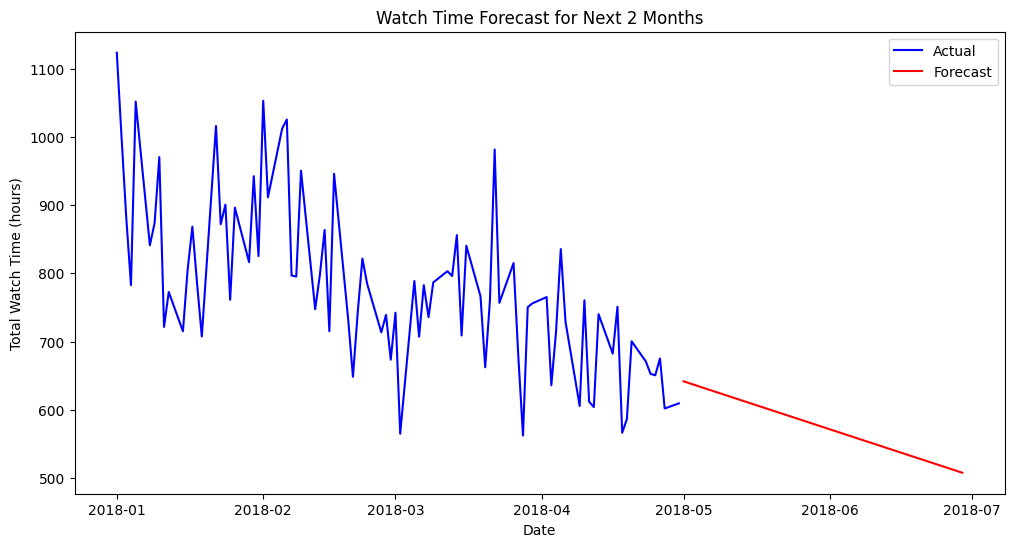

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['date_'], y, label="Actual", color="blue")
plt.plot(forecast_df['date_'], forecast_df['predicted_watch_time'], label="Forecast", color="red")
plt.title("Watch Time Forecast for Next 2 Months")
plt.xlabel("Date")
plt.ylabel("Total Watch Time (hours)")
plt.legend()
plt.show()
